# Evaluating Methods for Covariate Selection in Experimental Designs

Kendra Wyant (Department of Psychology, University of Wisconsin-Madison)  
Lauren Khoury (Department of Psychology, University of Wisconsin-Madison)  
Markus Brauer (Department of Psychology, University of Wisconsin-Madison)  
John J. Curtin (Department of Psychology, University of Wisconsin-Madison)  
April 16, 2026

Including covariates when testing an experimentally manipulated independent variable ($X$) can reduce Type II error by accounting for additional variance in the outcome. Selecting optimal covariates, however, is challenging. Iterating over many covariates and retaining only those that increase the $X$ effect (*p*-hacking) substantially inflates Type I error. Consequently, researchers often adopt two extremes: including no covariates or all covariates. Although these approaches do not nominally increase Type I error rates, both can reduce power. Data-driven approaches may offer a more effective alternative.

We simulated 40,000 datasets across 540 research contexts varying in effect size, sample size, number of covariates, and covariate-outcome relationships. We evaluated nine selection methods: two traditional approaches (no covariates, all covariates) and seven data-driven approaches using covariate screening models (*p*-hacking, linear models that screen each covariate separately with and without $X$, linear models that screen all covariates simultaneously with and without $X$, and LASSO models that screen all covariates simultaneously with and without $X$).

We calculated the probability of Type I and Type II errors across methods and research contexts. Our results provide strong evidence of the benefits of using covariates and provide practical guidance for selecting covariates in experimental research.

# Introduction

Research in Psychology often uses experimental manipulations to establish causal relationships between a focal independent variable (IV) and a psychological outcome. For example, participants may be randomly assigned to receive a moderate dose of alcohol or placebo to evaluate the effect of alcohol consumption on response to a laboratory stressor ([Bradford, Shapiro, and Curtin 2013](#ref-bradfordHowBadCould2013); [Hefner et al. 2013](#ref-hefnerAlcoholStressResponse2013)). \[Markus, can you provide a simple second example that focuses on an IV manipulation that is social psych relevant?)

A valid test of the effect of an IV requires adequate statistical power ([Cohen 1988](#ref-cohenStatisticalPowerAnalysis1988), [1992](#ref-cohenPowerPrimer1992)). By definition, low statistical power is associated with a high probability of a Type II error (i.e., failure to reject a false null hypothesis). Furthermore, significant effects detected by low-powered studies may not replicate (due to low positive predictive value) and estimates of their effect size may be positively biased (due to publication bias). For all these reasons, methods to reduce Type II errors are critically important for a robust scientific literature ([Cohen 1962](#ref-cohenStatisticalPowerAbnormalsocial1962); [Button et al. 2013](#ref-buttonPowerFailureWhy2013)).

The use of covariates that are measured at baseline (i.e., prior to random assignment/manipulation of the focal IV) has been shown to reduce Type II errors by accounting for unexplained variance in the outcome that would otherwise be treated as noise in the analysis ([Thompson et al. 2015](#ref-thompsonCovariateAdjustmentHad2015); [Adrián V. Hernández, Steyerberg, and Habbema 2004](#ref-hernandezCovariateAdjustmentRandomized2004); [Adrián V. Hernández, Eijkemans, and Steyerberg 2006](#ref-hernandezRandomizedControlledTrials2006); [Kahan et al. 2014](#ref-kahanRisksRewardsCovariate2014); [Van Breukelen 2006](#ref-vanbreukelenANCOVAChangeBaseline2006); [Egbewale, Lewis, and Sim 2014](#ref-egbewaleBiasPrecisionStatistical2014)). For example, in the previously described test of the effect of alcohol on stress response, baseline measures of both trait anxiety and fearfulness could be included as covariates. These measures would not be systematically correlated with the IV because they are collected prior to random assignment. They would also be expected to correlate with laboratory stress response based on prior research. Given this, the addition of these measures as covariates in the analysis could reduce variance in stress response that is unrelated to the manipulation and lower the probability of a Type II error for the IV effect.

However, selection of the optimal covariates to reduce Type II error is not straightforward. Historically, researchers often iterated over a large set of available covariates and included only those covariates that increased the effect size of the test of their focal IV (and their chances of obtaining a significant *p*-value). Today, we recognize that this approach, known as *p*-hacking ([Simonsohn, Nelson, and Simmons 2014](#ref-simonsohnPcurveKeyFiledrawer2014)), seriously undermines the statistical validity of the analyses by substantially increasing the probability of Type I errors (i.e., rejecting the null hypothesis when it is not false ([Simmons, Nelson, and Simonsohn 2011](#ref-simmonsFalsepositivePsychologyUndisclosed2011); [Ioannidis 2005](#ref-ioannidisWhyMostPublished2005); [Schelchter and Forsythe 1985](#ref-schelchterPosthocSelectionCovariates1985); [Beach and Meier 1989](#ref-beachChoosingCovariatesAnalysis1989))). Statistically valid analyses require both low probability of Type II errors and control of Type I errors at the specified value of alpha (e.g., 0.05).

Given that *p*-hacking compromises statistical validity, we are left with questions about appropriate covariate selection approaches that both minimize Type II errors and control Type I errors at alpha. Traditionally, researchers have relied on two somewhat extreme strategies for selecting covariates. At one end, the researcher could decide to avoid the use of covariates altogether with no risk to Type I error control. But statistical power would likely be lost by this decision.<!--did we want to avoid using the term power?--> At the other extreme, the researcher could plan to include all available covariates that are reasonably believed to account for unexplained variance in the outcome in the statistical analysis. This decision, if made a priori<!--KW: noting use of a priori, not sure if we want to keep or change wording-->, would also not be expected to inflate the Type I error rate. However, this approach may not yield optimal statistical power because a subset of these covariates may not manifest strong, or any, relationship with the outcome in any particular study if they have not been previously well-established as robust predictors. Furthermore, available covariates are often correlated with each other (e.g., trait anxiety and fearfulness from the previous example), which reduces their potential benefit in reducing noise relative to their cost to degrees of freedom in the analysis.

Given these possibly sub-optimal previous options, it may be that a data-driven approach to covariate selection could improve statistical validity relative to the traditional all or no covariate approaches. An optimal data-driven covariate selection method may be able to select the covariates that provide the greatest reduction in Type II error rate (e.g., covariates highly correlated with the outcome ([Kahan et al. 2014](#ref-kahanRisksRewardsCovariate2014))) with the lowest cost to degrees of freedom (e.g., by including only covariates that contribute to unique reductions in variance). Of course, statistically valid data-driven approaches must also not meaningfully inflate the Type I error rate, as occurs with *p*-hacking.

To be clear, this paper paper discusses the benefits of using covariates in experimental research where covariates are measured at baseline, prior to manipulation of the IV, and therefore uncorrelated with the IV. In such instances, covariates are a powerful yet simple tool to increase statistical power without adding any complexity to the interpretation of the effect of the IV. However, in some areas of Psychology (e.g., clinical), covariates are routinely used for a different goal - to control for baseline differences across groups when participants were not randomly assigned to groups. In these instances, covariates should be selected using other approaches not considered in this paper (e.g., based on theory and/or putative causal structure among $X$ and covariates). Furthermore, researchers should carefully consider if the interpretative complexity introduced by this alternative use of correlated covariates is warranted and meets their goals ([Miller and Chapman 2001](#ref-millerMisunderstandingAnalysisCovariance2001)).

In this study, we use simulation methods to evaluate two traditional (“no covariates” and “all covariates”) and seven data-driven approaches to select an optimal set of covariates when testing the effect of a focal manipulated IV. For each data-driven approach, we use covariate “screening models” to identify which covariates display significant relationships with the outcome variable and will be included in the subsequent primary analysis that tests the focal IV<!--This is no longer true for p-hacking-->. Across these screening models, we consider *p*-hacking (a statistically invalid data-driven approach) and three additional modeling approaches: linear models that screen each covariate separately in its own model (separate cov lm), linear models that screen all covariates simultaneously in a single model (simultaneous cov lm), and LASSO ([Tibshirani 1996](#ref-tibshiraniRegressionShrinkageSelection1996a)) models that screen all covariates simultaneously in a single model (simultaneous cov LASSO). Across the three modeling approaches, we also either include or exclude the focal IV in the screening models. For all approaches we quantify the probability of Type I and Type II errors across a variety of research contexts that vary by sample size, number of available covariates, strength of covariate effects, effect size for the IV and other relevant context characteristics. We use results from these simulations to provide clear and accessible guidance about how best to select an optimal set of covariates to increase statistical power<!--KW: reduce Type II error?--> when testing the effect of a manipulated IV in various research contexts.

# Methods

## Covariate Selection Approaches

As described above, we evaluated two traditional and seven data-driven approaches to select covariates to use in a primary analysis that tested the effect of a focal dichotomous IV (notated as $X$). A summary of these nine approaches is presented in <a href="#tbl-methods" class="quarto-xref">Table 1</a>.

The two traditional selection approaches that did not use the data to screen and select covariates. Instead the no covariates and all covariates approach used none and all of the available covariates, respectively, in the specific research context in the primary analysis of $X$.

For the seven data-driven approaches, we selected covariates for the primary analysis of $X$ by fitting preliminary covariate screening models. For the *p*-hacking approach, covariates were selected to be included in the primary analysis if the effect of $X$ became larger in the screening model that included that covariate. This replicates the real-world practice of *p*-hacking where researchers aim to increase the effect size of a focal variable to match a pre-existing hypothesis.

We considered three additional modeling approaches: linear models that screen each covariate separately in its own model (separate cov lm)<!--I think we should define these here, but if we end up keeping methods in last paragraph of intro only use abbreviation here-->, linear models that screen all covariates simultaneously in a single model (simultaneous cov lm), and LASSO ([Tibshirani 1996](#ref-tibshiraniRegressionShrinkageSelection1996a)) models that screen all covariates simultaneously in a single model (simultaneous cov LASSO). Across these approaches, we also either include or exclude $X$ in the screening models (notated as with or w/o $X$). For the simultaneous cov LASSO with $X$ approach, we set the regularization penalty (lambda) for $X$ was to 0 to ensure it was always retained in the screening model.

For the linear models (separate cov lm with $X$, separate cov lm w/o $X$, simultaneous cov lm with $X$, and simultaneous cov lm w/o $X$), a covariate was selected to be included in the primary analysis if the *p*-value for that covariate was less than 0.05 in the screening model that evaluated it. Importantly, the *p*-value for $X$ was not used and $X$ was only included to parse its variance from $Y$ when evaluating the covariates. For the LASSO models (simultaneous cov LASSO with $X$ and simultaneous cov LASS w/o $X$), covariates were selected to be included in the primary analysis if they were retained in the screening model (i.e., did not have their parameter estimate set to 0).

``` python
lm_methods |> 
  kbl(escape = FALSE, format = "html") |> 
  kable_classic() |> 
  kableExtra::footnote(general = footnote_methods, escape=FALSE)
```

    Warning in attr(x, "align"): 'xfun::attr()' is deprecated.
    Use 'xfun::attr2()' instead.
    See help("Deprecated")

<table class="lightable-classic do-not-create-environment cell" data-quarto-postprocess="true" style="font-family: &quot;Arial Narrow&quot;, &quot;Source Sans Pro&quot;, sans-serif; margin-left: auto; margin-right: auto;border-bottom: 0;">
<colgroup>
<col style="width: 33%" />
<col style="width: 33%" />
<col style="width: 33%" />
</colgroup>
<thead>
<tr>
<th style="text-align: left;" data-quarto-table-cell-role="th">Method</th>
<th style="text-align: left;" data-quarto-table-cell-role="th">Screening Models</th>
<th style="text-align: left;" data-quarto-table-cell-role="th">Covariate Selection Criteria</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left;">No covariates</td>
<td style="text-align: left;">No screening models</td>
<td style="text-align: left;">No covariates used</td>
</tr>
<tr>
<td style="text-align: left;">All covariates</td>
<td style="text-align: left;">No screening models</td>
<td style="text-align: left;">All covariates used</td>
</tr>
<tr>
<td style="text-align: left;">p-hacking</td>
<td style="text-align: left;">\(Y \sim X + C_{1}\)<br />
\(Y \sim X + C_{2}\)<br />
\(\vdots\)<br />
\(Y \sim X + C_{k}\)</td>
<td style="text-align: left;">Covariates that increase the effect of \(X\) are included in the final model</td>
</tr>
<tr>
<td style="text-align: left;">Separate cov lm with X</td>
<td style="text-align: left;">\(Y \sim X + C_{1}\)<br />
\(Y \sim X + C_{2}\)<br />
\(\vdots\)<br />
\(Y \sim X + C_{k}\)</td>
<td style="text-align: left;">Significant covariates (\(p &lt; .05\)) when controlling for \(X\) are included in the final model</td>
</tr>
<tr>
<td style="text-align: left;">Separate cov lm w/o X</td>
<td style="text-align: left;">\(Y \sim C_{1}\)<br />
\(Y \sim C_{2}\)<br />
\(\vdots\)<br />
\(Y \sim C_{k}\)</td>
<td style="text-align: left;">Significant covariates (\(p &lt; .05\)) are included in the final model</td>
</tr>
<tr>
<td style="text-align: left;">Simultaneous cov lm with X</td>
<td style="text-align: left;">\(Y \sim X + C_{1} + C_{2} + \cdots + C_{k}\)</td>
<td style="text-align: left;">Significant covariates (\(p &lt; .05\)) when controlling for \(X\) and all other covariates are retained in the final model</td>
</tr>
<tr>
<td style="text-align: left;">Simultaneous cov lm w/o X</td>
<td style="text-align: left;">\(Y \sim C_{1} + C_{2} + \cdots + C_{k}\)</td>
<td style="text-align: left;">Significant covariates (\(p &lt; .05\)) when controlling for all other covariates are included in the final model</td>
</tr>
<tr>
<td style="text-align: left;">Simultaneous cov LASSO with X</td>
<td style="text-align: left;">\(Y \sim X + C_{1} + C_{2} + \cdots + C_{k}\) with \(\lambda\) penalty applied to all covariates</td>
<td style="text-align: left;">Covariates with non-zero coefficients are included in the model</td>
</tr>
<tr>
<td style="text-align: left;">Simultaneous cov LASSO w/o X</td>
<td style="text-align: left;">\(Y \sim C_{1} + C_{2} + \cdots + C_{k}\) with \(\lambda\) penalty applied to all covariates</td>
<td style="text-align: left;">Covariates with non-zero coefficients are included in the model</td>
</tr>
</tbody><tfoot>
<tr>
<td style="text-align: left; padding: 0;"><span style="font-style: italic;">Note: </span></td>
<td style="text-align: left;"></td>
<td style="text-align: left;"></td>
</tr>
<tr>
<td style="text-align: left; padding: 0;"><sup></sup> Screening models represent symbolic linear models where \(Y\) is the outcome, \(X\) is the focal independent variable, \(C\) is a covariate, and \(k\) is the number of covariates.</td>
<td style="text-align: left;"></td>
<td style="text-align: left;"></td>
</tr>
</tfoot>
&#10;</table>

Table 1: The nine covariate selection models and their definition for covariate selection.

## Research Contexts

We manipulated several characteristics designed to mimic a range of research contexts that researchers in psychology might encounter in their studies. We crossed all levels of each characteristic to create a total of 540 unique research contexts to allow results from our simulations to generalize across the diversity of contexts within which psychology studies are situated. A summary of these characteristics is presented in <a href="#tbl-dictionary" class="quarto-xref">Table 2</a>. They include:

1.  **The population parameter for the focal IV** ($\beta_X$). We selected values that represent null ($\beta_{X} = 0$), small ($\beta_{X} = 0.2$) and medium ($\beta_{X} = 0.5$) effect sizes for the IV. Given that the standard deviation of the outcome variable was set to 1 in all simulations, these parameter values correspond to null, small, and medium Cohen’s d effect sizes ([Cohen 1988](#ref-cohenStatisticalPowerAnalysis1988)).

2.  **The sample size** ($N$). We chose values for the number of observations that pertain to common sample sizes in experimental research in psychology: 50, 100, 150, 200, 300, and 400 observations.

3.  **The number of covariates available** ($N_{cov}$). We selected a wide range of possible scenarios: 4, 8, 12, 16, or 20 available covariates.

4.  **The percentage of covariates with non-zero correlations with the outcome** ($\%_{cov}$). We simulated research contexts where 25%, 50% or 75% of the available covariates had non-zero correlations with the outcome in the population. This allowed us to model situations where the researcher has an exploratory vs. more well-established set of covariates at their disposal.

5.  **The magnitude of the correlation between the covariates and $Y$** ($r_{cov-Y}$). All non-zero covariates (see characteristic 4) were given a moderate or large relationship to the outcome $Y$ (i.e., $r_{cov-Y}$ = 0.3 or 0.5, respectively). Given that these covariates are all correlated with the outcome, it is expected that they would typically also be correlated with each other. Therefore, we assigned a moderate 0.3 correlation among each of these non-zero covariates.

``` python
data_tbl0 <- tibble(
  description = c(
    "The population parameter for the focal IV",
    "The sample size",
    "The number of covariates available",
    "The percentage of covariates with non-zero correlations with the outcome",
    "The magnitude of the correlation between the covariates and Y"),
  values = c("0, 0.2, 0.5",
             "50, 100, 150, 200, 300, 400", 
             "4, 8, 12, 16, 20", 
             "0.25, 0.50, 0.75",
             "0.3, 0.5" 
             )
)

data_tbl0 |>
  kbl(col.names = c("Research Context Variable", "Values"), 
      escape = FALSE,
      format = "html") |>
  kable_styling(bootstrap_options = c("striped"), 
                full_width = FALSE) |>
  column_spec(1, width = "15em") |>
  column_spec(2, width = "10em")
```

    Warning in attr(x, "align"): 'xfun::attr()' is deprecated.
    Use 'xfun::attr2()' instead.
    See help("Deprecated")

| Research Context Variable | Values |
|:---|:---|
| The population parameter for the focal IV | 0, 0.2, 0.5 |
| The sample size | 50, 100, 150, 200, 300, 400 |
| The number of covariates available | 4, 8, 12, 16, 20 |
| The percentage of covariates with non-zero correlations with the outcome | 0.25, 0.50, 0.75 |
| The magnitude of the correlation between the covariates and Y | 0.3, 0.5 |

Table 2: Research context variables and values

## Data Analytic Plan

All data analyses were done in R using the Tidyverse ecosystem ([Kuhn and Wickham 2020](#ref-kuhnTidymodelsCollectionPackages2020)) and the RStudio IDE ([RStudio Team 2020](#ref-rstudioteamRStudioIntegratedDevelopment2020)). Simulations were run using high-throughput computing resources provided by the University of Wisconsin-Madison Center for High Throughput Computing ([Center for High Throughput Computing 2006](#ref-chtc)).

We simulated 40,000 datasets within each research context. For each simulated dataset, we generated scores for a dichotomous focal IV ($X$), varying numbers of quantitative covariates ($C$), and a quantitative outcome ($Y$). To generate these datasets, we first created $N$ scores for a set of multivariate normal distributed covariates and $Y$, with their variances = 1 and the number of covariates, and the covariances among the covariates and with $Y$ dictated with the research context (see points 3-5 above). Consistent with the manipulation of the IV following measurement of the baseline covariates, the effect of $X$ was ($\beta_X * X$) was then added into $Y$.

Below, we display an exemplar covariance matrix and subsequent R code to generate a single simulated dataset for a research context with a small population effect size for the IV ($\beta_{X} = 0.2$), a sample size of 100, and four covariates, where 50% of the covariates have a 0.50 correlation with the outcome and 0.30 correlations with each other.

This is the relevant covariance matrix (sigma).

In [ ]:
sigma <- matrix(c(
  1.0, 0.5, 0.5, 0.0, 0.0,
  0.5, 1.0, 0.3, 0.0, 0.0,
  0.5, 0.3, 1.0, 0.0, 0.0,
  0.0, 0.0, 0.0, 1.0, 0.0,
  0.0, 0.0, 0.0, 0.0, 1.0
), nrow = 5, byrow = TRUE)

rownames(sigma) <- c("Y", "C1", "C2", "C3", "C4")
colnames(sigma) <- c("Y", "C1", "C2", "C3", "C4")


print(formatC(sigma, format = "f", digits = 1), quote = FALSE)

   Y   C1  C2  C3  C4 
Y  1.0 0.5 0.5 0.0 0.0
C1 0.5 1.0 0.3 0.0 0.0
C2 0.5 0.3 1.0 0.0 0.0
C3 0.0 0.0 0.0 1.0 0.0
C4 0.0 0.0 0.0 0.0 1.0

The covariance matrix can then be used to generate a multivariate normal dataset of $Y$ and $C_1...C_4$ for 100 observations where all variables have a mean of 0. Following this, the effect of the IV ($X$) can be added into $Y$.

In [ ]:
df <- MASS::mvrnorm(n = 100, mu = c(0, 0, 0, 0, 0), Sigma = sigma)

x <- rep(c(-.5, .5), each = 50)
df[, 1] <- df[, 1]+ .2 * x

For each simulated dataset in each research context, we used each of the 9 covariate selection approaches to determine which covariates to use in the primary analysis to test the effect of $X$ on $Y$. For example, if the selection approach selected covariates 1 and 4, the primary analysis would be $lm(Y \sim X + C_1 + C_4, \text{data} = \text{df})$. From each primary analysis, we saved the research context characteristics, the covariate selection approach used, and the parameter estimate for $X$, *p*-value for its statistical test against 0, and the conclusion (reject or fail to reject) using alpha = 0.05.

We provided descriptive statistics and sampling distributions (from the 40,000 simulations) of the parameter estimate for $X$ across research contexts for each covariate selection approach, separately by true effect size for $X$ (0, 0.2, and 0.5). For research contexts where the population parameter for $X$ was 0 (i.e., $X$ has no effect on $Y$), we assessed and reported the Type I error rates associated with each covariate selection approach by research context characteristics. For research contexts where the population parameter for $X$ was 0.2 or 0.5 (i.e., $X$ has an effect on $Y$), we assessed and reported the Type II error rate for each covariate selection method by research context characteristics. An interactive shiny dashboard of mean error rates for all combinations of research context variables is accessible through our OSF page (<https://osf.io/zh5gn/>).

# Results

## Parameter Estimates

When the assumptions of the linear model are met, parameter estimates are unbiased (i.e. the mean of the parameter estimate’s sampling distribution equals the value of the population parameter) and their sampling distributions follow the t-distribution. To evaluate the impact of the screening approaches on the parameter estimate (i.e., $b_X$), <a href="#tbl-est" class="quarto-xref">Table 3</a> shows the mean parameter estimate from our primary analysis for each covariate screening approach across research contexts (with 40,000 sample parameter estimates per context), separately by population effect size ($\beta_X = 0$, $\beta_X = 0.2$, $\beta_X = 0.5$).

``` python
table |> 
  rename(Method = method, 
         `No effect ($\\beta_{x}=0$)` = `0`,
         `$\\beta_{x}=0.2$` = `0.2`,
         `$\\beta_{x}=0.5$` = `0.5`) |> 
  mutate(
    Method = factor(
      Method,
      levels = c("no_covs", "all_covs", "p_hacked", 
                 "r", "partial_r", 
                   "full_lm_wo_x", "full_lm",
                 "lasso",  "lasso_wo_x"),
      labels = c("No covariates", "All covariates", "p-hacking", 
                 "Separate cov lm with X", 
                 "Separate cov lm w/o X", 
                 "Simultaneous cov lm with X", 
                 "Simultaneous cov lm w/o X", 
                 "Simultaneous cov LASSO with X", 
                 "Simultaneous cov LASSO w/o X")
    )
  ) |> 
  mutate(across(-Method, ~sprintf("%.3f", abs(.)))) |> 
  arrange(Method) |> 
  add_row(Method = "Traditional Selection", .before = 1) |> 
  add_row(Method = "Data-driven Selection", .after = 3) |> 
  kable(escape = FALSE) |> 
  kable_classic() |> 
  pack_rows(NULL, 2, 3) |> 
  pack_rows(NULL, 5, 11)
```

    Warning in attr(x, "align"): 'xfun::attr()' is deprecated.
    Use 'xfun::attr2()' instead.
    See help("Deprecated")
    Warning in attr(x, "align"): 'xfun::attr()' is deprecated.
    Use 'xfun::attr2()' instead.
    See help("Deprecated")

| Method | No effect (\$\beta\_{x}=0\$) | \$\beta\_{x}=0.2\$ | \$\beta\_{x}=0.5\$ |
|:---|:---|:---|:---|
| Traditional Selection |  |  |  |
|  |  |  |  |
| No covariates | 0.000 | 0.200 | 0.500 |
| All covariates | 0.000 | 0.200 | 0.500 |
| Data-driven Selection |  |  |  |
|  |  |  |  |
| p-hacking | 0.000 | 0.262 | 0.563 |
| Separate cov lm with X | 0.000 | 0.198 | 0.495 |
| Separate cov lm w/o X | 0.000 | 0.200 | 0.500 |
| Simultaneous cov lm with X | 0.000 | 0.192 | 0.479 |
| Simultaneous cov lm w/o X | 0.000 | 0.200 | 0.500 |
| Simultaneous cov LASSO with X | 0.000 | 0.200 | 0.500 |
| Simultaneous cov LASSO w/o X | 0.000 | 0.195 | 0.487 |

Table 3: Mean estimates of effect size by method and population parameter.

We also display the associated sampling distributions for these parameter estimates for each approach and population effect size in <a href="#fig-panel-2" class="quarto-xref">Figure 5</a>.

``` python
est_d_0 / est_d_02 / est_d_05
```

<figure id="fig-distribution-bx">
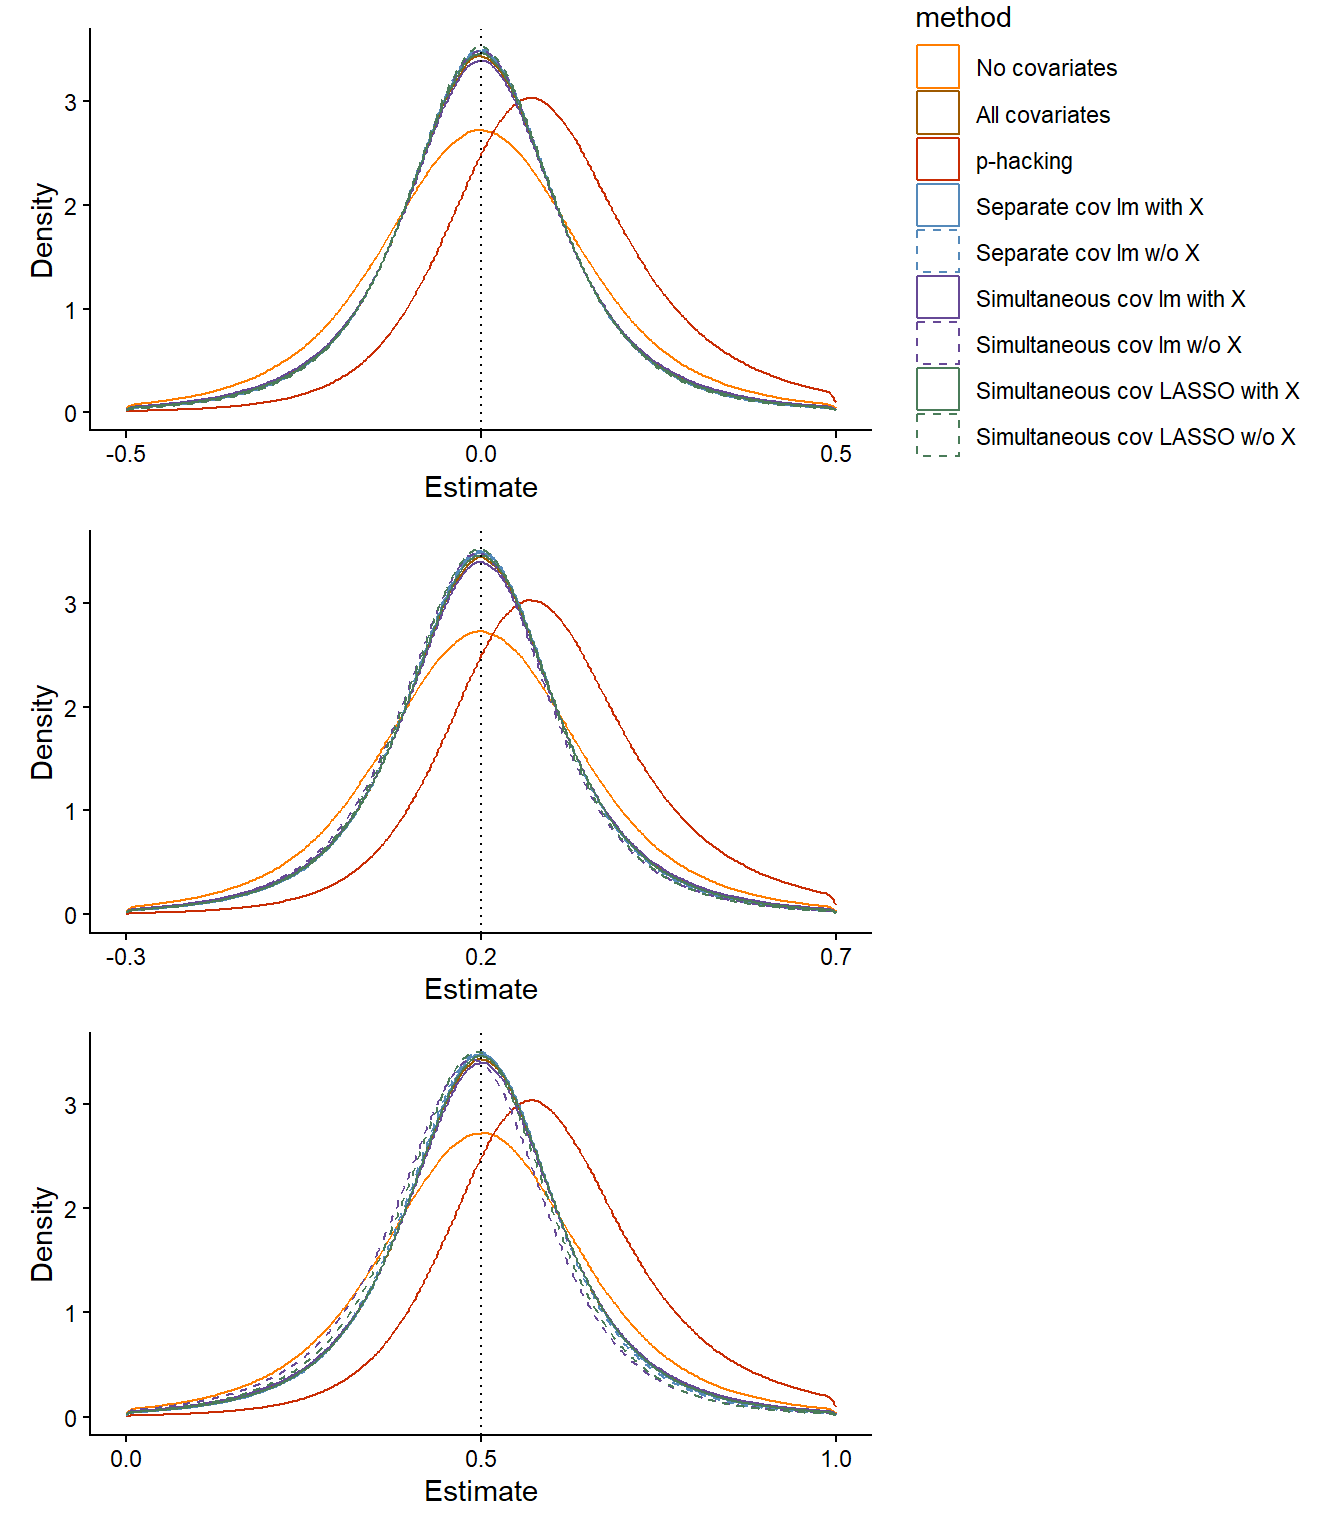
<figcaption>Figure 1: Sampling distributions for population parameter estimates displayed separately by selection method and population parameter. Selection methods that do not control for X are displayed as dashed lines.</figcaption>
</figure>

First, we considered contexts where the population effect size was 0 ($\beta_X$ = 0). In these contexts, all approaches yielded unbiased estimates. However, the shape of the sampling distribution for the *p*-hacking approach was clearly distorted (bi-modal).<!--update after new analyses--> This distortion results from this approach selecting covariates that magnify the effect of $X$ in any specific sample. When sampling error produces a negative $b_X$ in a sample, covariates that make that parameter estimate more negative will be selected, and when sampling error produces a positive $b_X$ in a sample, covariates that make that parameter estimate more positive will be selected. This is what produces the intolerably high Type I error rates associated with that approach.

Next, we considered contexts where there was a non-zero population effect for $X$. In these contexts, *p*-hacking yielded substantial optimistic (over-estimation) bias in the parameter estimates as seen in both the mean $b_X$ and the rightward shift of the sampling distribution. In this instance, the sample $b_X$ was typically positive to start (given the positive population parameter) and covariates were selected only if they made that parameter estimate even more positive.

Of course, the traditional approaches (no covariates, all covariates) produced unbiased $b_X$ because the linear model in the primary analysis that tested the effect of $X$ was used without any prior screening of covariates in separate analyses. The remaining data-driven approaches that included $X$ also yielded unbiased $b_X$ because the covariates were selected only based on their unique (partial) relationship with $Y$ after removing any modest correlation between the covariates and $X$ due to sampling error (remember that any correlation between $X$ and a covariate in a specific sample is due to noise in that sample because covariates are measured prior to IV manipulation). Given this, when selected covariates were included in the primary analysis, they did not systematically increase or decrease $b_X$.

In contrast, when the screening model did not include $X$, covariates that are positively correlated with $X$ in the sample (due to noise) are selected at a slightly higher rate because this spurious correlation further increased their positive correlation with $Y$ (given that $\beta_X$ was also positive). When these covariates are subsequently included in the primary analysis of $X$, they systematically remove some of the true causal effect $X$ on $Y$ and result in a pessimistic (under-estimation) bias in the estimate of $\beta_X$.

## Type I Error

Given our use of simulated datasets, we were able to set the true population parameter for $X$ to be zero (i.e., $\beta_X = 0$). Therefore, any significant result was a Type I error. <a href="#fig-bar-1" class="quarto-xref">Figure 2</a> shows the average Type I error rate across all research contexts for each approach. The *p*-hacking approach for selecting covariates, unsurprisingly led to a highly inflated mean Type I error rate across contexts, consistent with the extant research published in the last several years on the connection between researcher degrees of freedom and false positives<!--kendra Insert refs-->}. The other approaches were at or near the expected error rate of alpha = .05 across the relatively broad range of research context characteristics we considered. Specifically, the two traditional selection approaches and the data-driven selection approaches that did not include $X$ in the screening model displayed mean Type I error rates of exactly .05. The data-driven approaches that did include $X$ in the screening model (excluding *p*-hacking) displayed slightly increased (\<= .06) mean Type I error rates across contexts.

``` python
# ---- Parameters
gap_after_idx <- c(2,  3, 5, 7)  
gap_size <- 0.2                
bar_width <- 0.9                


df <- type_I_summary |>
  mutate(method_chr = as.character(method))


n <- nrow(df)
base_pos <- seq_len(n)  

# compute how many gaps precede each bar
gap_count_before <- sapply(base_pos, function(i) sum(gap_after_idx < i))
# add the total gap length before each bar
x_pos <- base_pos + gap_count_before * gap_size

plot_df <- df |>
  mutate(x_pos = x_pos)


x_breaks <- plot_df$x_pos
x_labels <- c("No covariates", "All covariates", "p-hacking", 
              "With X", "W/o X",
              "With X", "W/o X",
              "With X", "W/o X")

segment_labels <- tibble::tibble(
  x = c(mean(c(0.5, 2.6)),
        mean(c(2.8, 10.2)),
        mean(c(4.0, 5.8)),
        mean(c(6.2, 8.0)),
        mean(c(8.4, 10.2))),
  y = c(.22, .22, .08, .08, .08) + 0.015,   
  label = c("Traditional selection", "Data-driven selection", "Separate cov lm", "Simultaneous cov lm", "Simultaneous cov LASSO")
)

ggplot(
  plot_df,
  aes(x = x_pos, y = type_I, fill = method, pattern = method)
) +
  geom_bar_pattern(
    stat = "identity",
    width = bar_width,
    pattern_colour = "white",
    pattern_fill = "white",
    pattern_angle = 45,
    pattern_density = 0.6,
    pattern_spacing = 0.02,
    color = "black"
  ) +
  geom_segment(aes(y = .22, x = .5, xend = 2.6)) +
  geom_segment(aes(y = .22, x = 2.8, xend = 10.2)) +
  geom_segment(aes(y = .08, x = 4.0, xend = 5.8)) +
  geom_segment(aes(y = .08, x = 6.2, xend = 8.0)) +
  geom_segment(aes(y = .08, x = 8.4, xend = 10.2)) +
  geom_text(
    aes(label = sprintf("%.3f", type_I)),
    vjust = -0.5
  ) +
    geom_text(
    data = segment_labels,
    aes(x = x, y = y, label = label),
    inherit.aes = FALSE
  ) +
  labs(x = NULL, y = "Type I Error") +
  scale_y_continuous(
    limits = c(0, max(type_I_summary$type_I) * 1.2),
    breaks = seq(0, max(type_I_summary$type_I) * 1.2, by = 0.05)
  ) +
  # numeric x with custom breaks/labels; gaps are just extra space between positions
  scale_x_continuous(
    breaks = x_breaks,
    labels = x_labels,
    expand = expansion(mult = c(0.02, 0.05)) 
  ) +
  scale_pattern_manual(values = method_patterns) +
  scale_fill_manual(values = method_colors) +
  theme(
    legend.position = "none"
  )
```

    Warning: Removed 9 rows containing missing values or values outside the scale range
    (`geom_segment()`).
    Removed 9 rows containing missing values or values outside the scale range
    (`geom_segment()`).Warning: Removed 2 rows containing missing values or values outside the scale range
    (`geom_text()`).

<figure id="fig-bar-1">
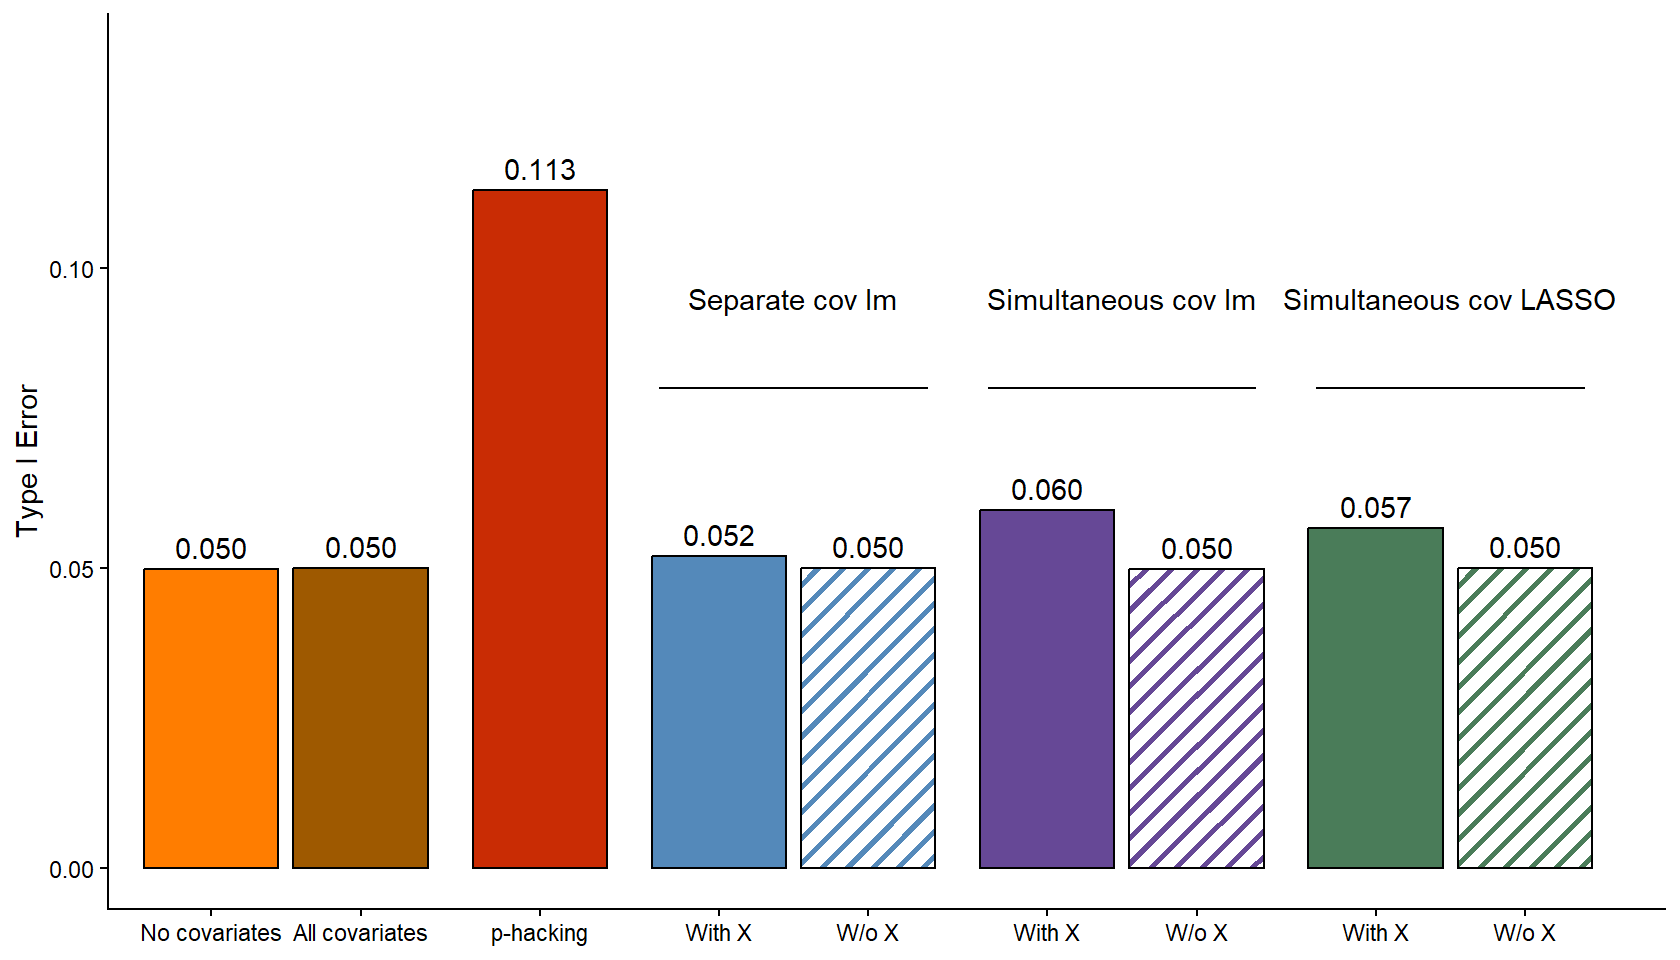
<figcaption>Figure 2: Type I Error by Method. Average type I error rate across all research contexts is displayed for each method separately by color. Traditional selection methods are on the left, data-driven selection methods are on the right. Striped shading indicates data-driven selection methods that do not control for X.</figcaption>
</figure>

We next assessed how Type I error rates varied by specific dimensions of our research contexts and noted several patterns (<a href="#fig-type1-panel" class="quarto-xref">Figure 3</a>). First, the magnitude of Type I error rate inflation for the *p*-hacking approach substantially increased with increasing number of available covariates, larger correlations between the covariates and $Y$ (i.e., $r_{cov-Y}$ = 0.5), higher percentage of available covariates with non-zero correlations with $Y$, and smaller sample sizes. The Type I error rate for *p*-hacking reached 0.462 in the worst case context ($N$ = 50, 20 available covariates with $r_{cov-Y}$ = 0.5 for 75% of the covariate set; see Shiny dashboard for other contexts).

In contrast, to the *p*-hacking approach, the Type I error rates remained constant at 0.05 across all research context dimensions for the traditional approaches and the data-driven approaches that did not include $X$. Among the other data-driven approaches that did include $X$, small increases in Type I error rates were observed as the sample size decreased and the number of available covariates increased. However, Type I error rate inflation remained modest for these approaches even at the extremes of these two dimensions (up to 0.074 at $N$=50 and up to 0.066 with 20 covariates in the simultaneous linear model approach). And in the worst case context at the intersection of all dimensions, error rates for these screening approaches that included $X$ only reached 0.072 for separate linear models, 0.096 with a simultaneous linear model and 0.089 with a simultaneous LASSO. Neither the magnitude $r_{cov-Y}$ nor the percentage of available covariates with non-zero correlations with $Y$ appeared to have any systematic impact on the Type I error rates for the data-driven approaches that included $X$.

``` python
(observations + covs)/(good_covs + ycor) +
  plot_layout(guides = "collect") &
  theme(legend.position = "right")
```

<figure id="fig-type1-panel">
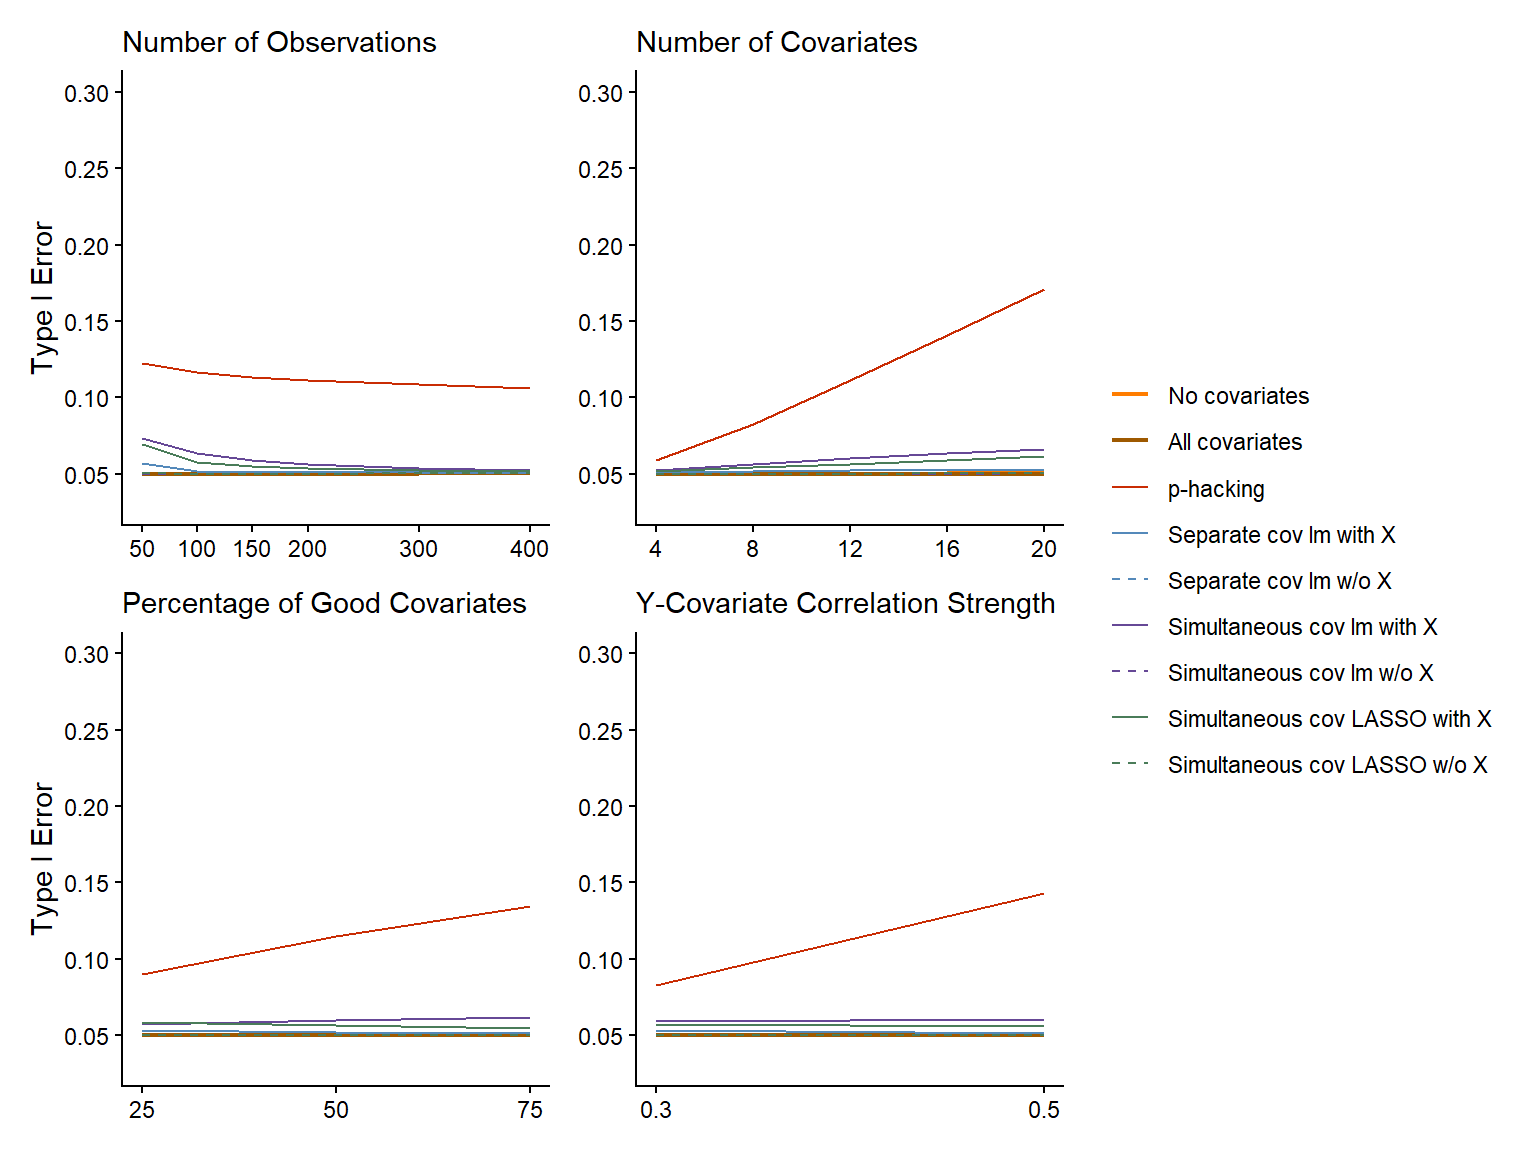
<figcaption>Figure 3: Type I error by method and research context. Plots are paneled by aspects of the research context: number of observations, number of covariates, percentage of good covariates (i.e., covariates with non-zero correlations with Y), and Y-covariate correlation strength. Methods are displayed separately by color. Data-driven selection methods that do not control for X are depicted as dashed lines.</figcaption>
</figure>

## Type II Error

We simulated datasets with two possible non-zero population parameters for the effect of $X$ on $Y$ ($\beta_X = 0.2$, $\beta_X = 0.5$). Given that we set the standard deviation of $Y$ to equal 1, these represented contexts where $X$ had a small (Cohen’s d = 0.2) or moderate (Cohen’s d = 0.5) effect on $Y$. In these simulations, non-significant effects for $X$ were, by definition, Type II errors. Given the substantial problems with Type I error rate inflation noted above, we do not consider the *p*-hacking approach to be viable and therefore did not evaluate Type II error rates for this approach.

<a href="#fig-bar-2" class="quarto-xref">Figure 4</a> shows the mean Type II error rate across all research contexts for each approach. The traditional no covariates approach displayed the highest average Type II error (0.449), which reinforces the value of using covariates to increase statistical power to detect true effects. Among the approaches that used covariates, the data-driven approaches generally produced modestly lower average Type II error rates than the traditional all covariates approach. Furthermore, the data-driven approaches that included $X$ displayed modestly lower mean Type II error rates than the comparable approaches that did not include $X$ in the screening model.

``` python
type_II_summary <- d_02 |>
  bind_rows(d_05) |> 
  filter(method != "p-hacking") |> 
  group_by(method) |>
  summarise(type_II = mean(type_II, .groups = "drop")) |> 
  mutate(group = case_match(method,
                            "p-hacking" ~ "p-hacking",
                            "No covariates" ~ "No selection",
                            "All covariates" ~ "No selection",
                            "Separate cov lm w/o X" ~ "Separate cov lm",
                            "Separate cov lm with X" ~ "Separate cov lm",
                            "Simultaneous cov lm w/o X" ~ "Simultaneous cov lm",
                            "Simultaneous cov lm with X" ~ "Simultaneous cov lm",
                            "Simultaneous cov LASSO w/o X" ~ "Simultaneous cov LASSO",
                            "Simultaneous cov LASSO with X" ~ "Simultaneous cov LASSO"))

# ---- Parameters
gap_after_idx <- c(2, 4, 6)  
gap_size <- 0.2                
bar_width <- 0.9                


df <- type_II_summary |>
  mutate(method_chr = as.character(method))


n <- nrow(df)
base_pos <- seq_len(n)  

# compute how many gaps precede each bar
gap_count_before <- sapply(base_pos, function(i) sum(gap_after_idx < i))
# add the total gap length before each bar
x_pos <- base_pos + gap_count_before * gap_size

plot_df <- df |>
  mutate(x_pos = x_pos)


x_breaks <- plot_df$x_pos
x_labels <- c("No covariates", "All covariates",
              "With X", "W/o X",
              "With X", "W/o X",
              "With X", "W/o X")

segment_labels <- tibble::tibble(
  x = c(mean(c(0.6, 2.6)),
        mean(c(2.8, 9.2)),
        mean(c(2.8, 4.6)),
        mean(c(5, 6.8)),
        mean(c(7.2, 9))),
  y = c(.50, .50, .40, .40, .40) + 0.015,   
  label = c("Traditional selection", "Data-driven selection", "Separate cov lm", "Simultaneous cov lm", "Simultaneous cov LASSO")
)


ggplot(
  plot_df,
  aes(x = x_pos, y = type_II, fill = method, pattern = method)
) +
   geom_bar_pattern(
    stat = "identity",
    width = bar_width,
    pattern_colour = "white",
    pattern_fill = "white",
    pattern_angle = 45,
    pattern_density = 0.6,
    pattern_spacing = 0.02,
    color = "black"
  ) +
  geom_segment(aes(y = .50, x = .6, xend = 2.6)) +
  geom_segment(aes(y = .50, x = 2.8, xend = 9.2)) +
  geom_segment(aes(y = .40, x = 2.8, xend = 4.6)) +
  geom_segment(aes(y = .40, x = 5, xend = 6.8)) +
  geom_segment(aes(y = .40, x = 7.2, xend = 9)) +
  geom_text(
    aes(label = sprintf("%.3f", type_II)),
    vjust = -0.5
  ) +
  geom_text(
    data = segment_labels,
    aes(x = x, y = y, label = label),
    inherit.aes = FALSE
  ) +
  labs(x = NULL, y = "Type II Error") +
  scale_y_continuous(
    limits = c(0, max(type_II_summary$type_II) * 1.2),
    breaks = seq(0, max(type_II_summary$type_II) * 1.2, by = 0.05)
  ) +
  # numeric x with custom breaks/labels; gaps are just extra space between positions
  scale_x_continuous(
    breaks = x_breaks,
    labels = x_labels,
    expand = expansion(mult = c(0.02, 0.05))  
  ) +
  scale_pattern_manual(values = method_patterns) +
  scale_fill_manual(values = method_colors) +
  theme(
    legend.position = "none"
  )
```

<figure id="fig-bar-2">
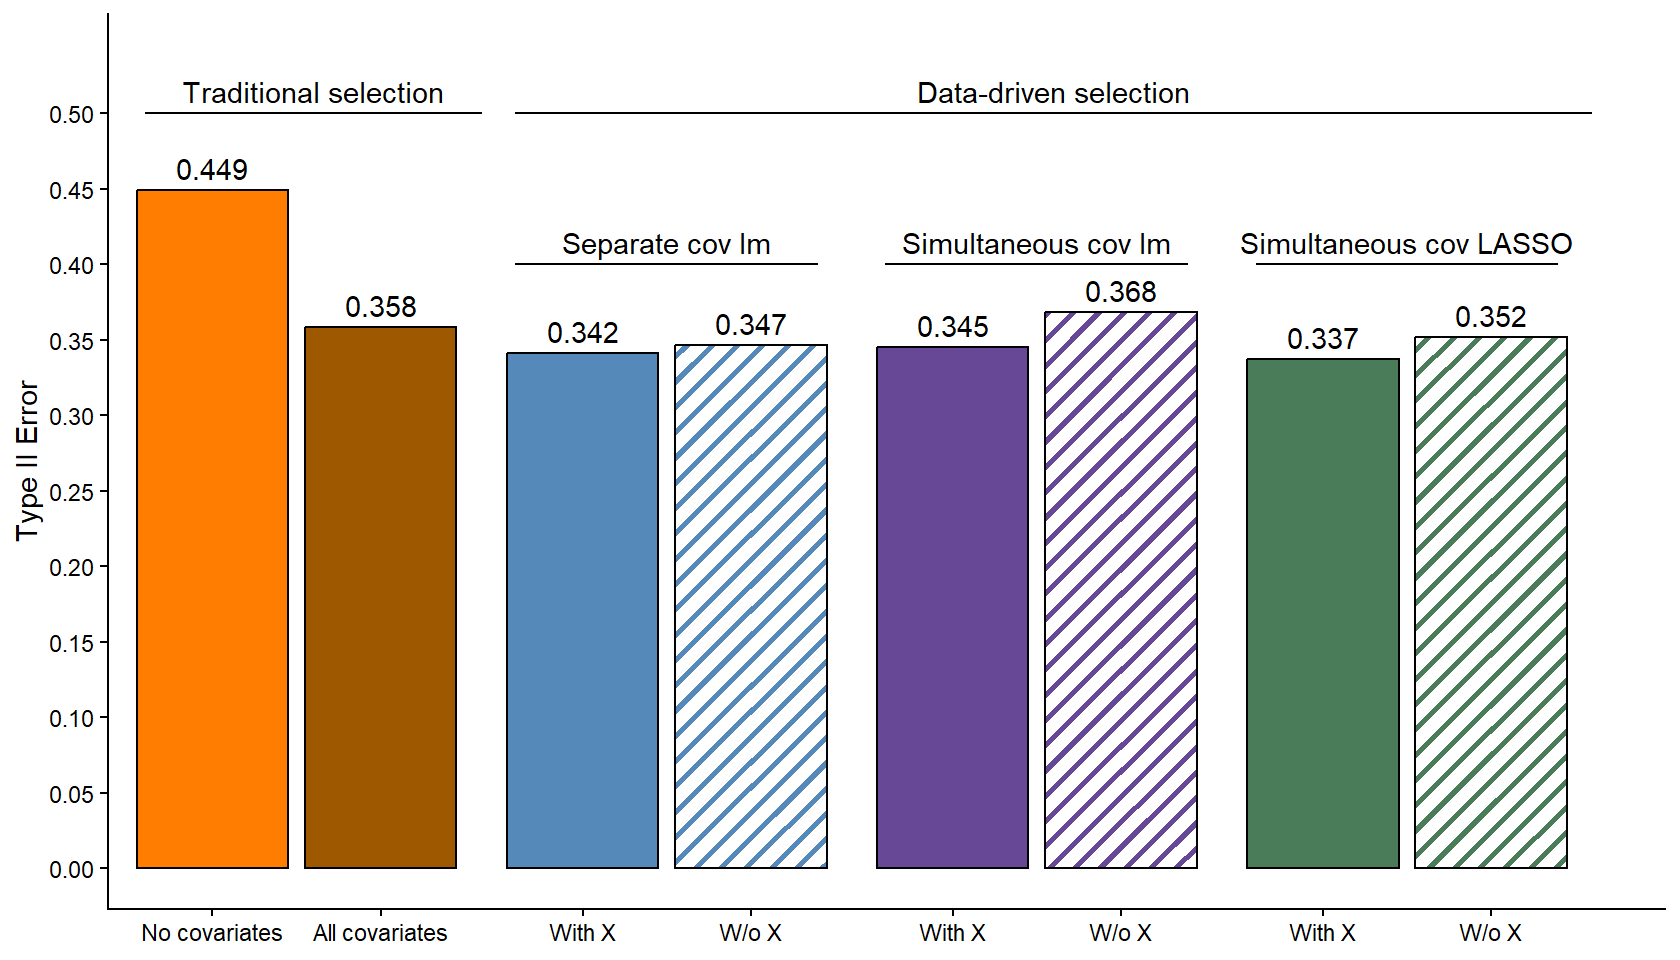
<figcaption>Figure 4: Type II Error by Method. Average type II error rate across all research settings is displayed for each method separately by color. Traditional selection methods are on the left, data-driven selection methods are on the right. Striped shading indicates data-driven selection methods that do not control for X.</figcaption>
</figure>

We next assessed how Type II error rates varied by specific dimensions of our research contexts and noted several patterns (<a href="#fig-panel-2" class="quarto-xref">Figure 5</a>). First, it is clear that the no covariates approach was always associated with the highest Type II error rates across all values of all dimensions of the research contexts. Second, the traditional all covariates approach tended to under-perform (i.e., higher Type II error rates) relative to the data-driven approaches when the sample size was low, the number of available covariates was high, or the percentage of available covariates with non-zero correlations with $Y$ was low. Similarly, the data-driven approaches that did not include $X$ tended to under-perform relative to the matched approaches that did include $X$ in these same contexts (low $N$, high number of covariates, low percentage of available covariates with non-zero correlations with $Y$).

``` python
  (observations_2 + covs_2)/(good_covs_2 + ycor_2)/(b_x + plot_spacer()) +
  plot_layout(guides = "collect") &
  theme(legend.position = "right")
```

<figure id="fig-panel-2">
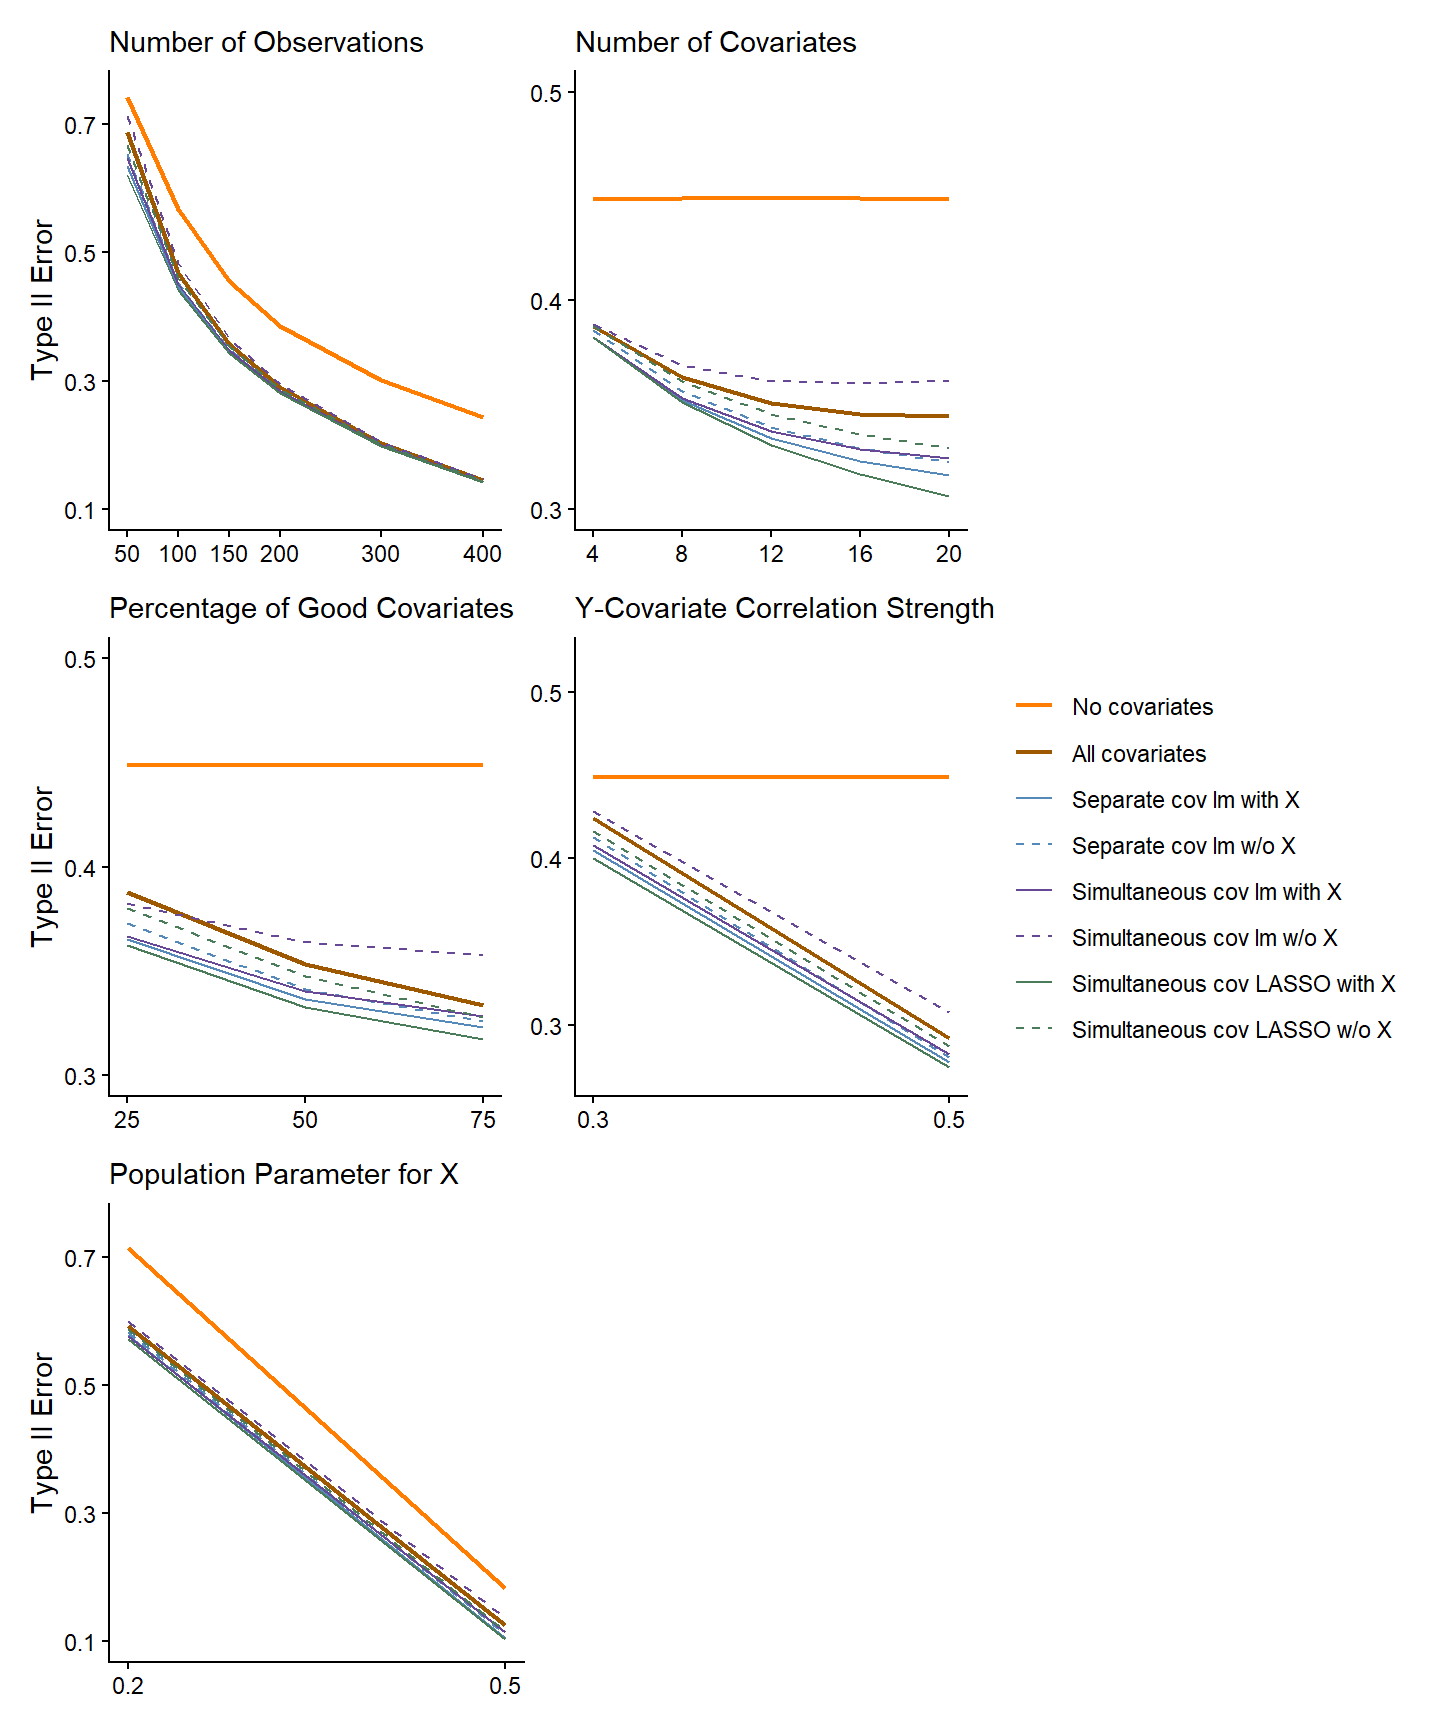
<figcaption>Figure 5: Type II error by method and research context. Plots are paneled by aspects of the research context: number of observations, number of covariates, percentage of good covariates covariates (i.e., covariates with non-zero correlations with Y), and Y-covariate correlation strength, and population parameter for X. Methods are displayed separately by color. Data-driven selection methods that do not control for X are depicted as dashed lines.</figcaption>
</figure>

# Discussion

Our findings reinforce the cautionary warning by Simmons and colleagues ([Simmons, Nelson, and Simonsohn 2011](#ref-simmonsFalsepositivePsychologyUndisclosed2011)): *p*-hacking can severely inflate Type I error rate. Simmons et al. observed a mean Type I error rate of 0.117 for the test of an IV when selecting between two potential covariates ($N$=40) using a *p*-hacking approach. Across our closest research contexts that included 4 covariates with N=50, we observed a comparable mean Type I error rate (0.103). However, our simulations clarify that this estimate may meaningfully underestimate the potential magnitude of the *p*-hacking problem in common research contexts. For example, researchers often can choose from among many more available covariates. With just a modest increase in the pool of available covariates (i.e., 8-12 covariates), our simulations show that mean Type I error rate for the *p*-hacking approach increased to 0.191. And if the size of the pool is increased further (i.e., 16-20 covariates), the mean Type I error rate is increased nearly 3-fold (0.295) from what was reported by Simmons et al., even when aggregated across contexts that include sample sizes up to $N$=400.

When no covariates were used (i.e., traditional no covariates approach<!--KW: I don't think this parenthetical definition is needed-->), the primary analysis of $X$ had a mean Type I error rate of 0.05 and provided an unbiased estimate of $\beta_X$ as expected given this traditional use of a linear model with its assumptions met. However, decisions regarding statistical validity must also consider an approach’s Type II error rate and the no covariates approach had a meaningfully higher Type II error rate compared to the other approaches. This should not be surprising. The use of covariates that are correlated with the outcome and uncorrelated with $X$ will account for additional variance in the outcome, thus increasing power (and decreasing Type II error rate). Of course, the relative cost to not use covariates (vs. other approaches) is higher when there are more covariates available and a higher percentage of them (e.g., 75%) have stronger relationships with $Y$ (e.g., $r_{cov-Y}$ = 0.5). In addition, the costs of ignoring available covariates are higher when the effect size for $X$ is smaller but also when the sample size is larger (such that the proportional reduction of degrees of freedom is smaller when covariate are added). We hope these results motivate increased use of covariates in experimental research.

Next, it should be acknowledged that the all covariates approach is a reasonable option in many research contexts. Like the no covariates approach, it had a mean Type I error rate of 0.05 and yielded an unbiased estimate of $\beta_X$. Yet across the range of values for all research dimensions (and almost all intersections that define specific research contexts), the Type II error rate for the all covariates approach was lower than the no covariates approach, confirming its superiority. Furthermore, the mean Type II error rate (aggregated across all research contexts) for the all covariates approach was only 0.015 - 0.020 higher than some of the best performing data-driven selection approaches while also being the easiest approach to implement computationally because it eliminates the need for screening models and selection.

Nonetheless, the data-driven covariate selection approaches are not difficult to implement (see examples of R code for each method shared on OSF <!--Kendra, lets talk about this-->) and it may never be wise to give up any improvements in power, even if modest. Moreover, the relative benefits of the best data-driven approaches are more substantial in some specific research contexts (e.g., small $N$, large number of more exploratory covariates available). In the best case example ($N$=50, $N_{cov}$=20, $r_{cov-Y}$=0.5, $\%_{cov}$=0.25 and $\beta_X$=0.5), the Type II error rate for the simultaneous cov LASSO with $X$ approach was 0.204 lower than the all covariates approach!

There are several issues to consider when comparing among the several top data-driven approaches. The approach with the lowest mean Type II error rate (0.337) was the simultaneous cov LASSO with $X$. This approach also provided an unbiased estimate of $\beta_X$. However, it had a slightly inflated Type I error rate (0.057) and the implementation of LASSO may be less familiar to some researchers (but see example code on OSF to implement it). Screening with separate cov lm with $X$ may feel easier, or more familiar to some researchers. This method yielded an unbiased estimate of $\beta_X$ with slightly worse Type II error rate (0.341) but better Type I error rate (0.052) than simultaneous cov LASSO with $X$. Finally, if perfect control of Type I error rate at the nominal alpha is desired, screening with separate cov lm w/o $X$ may be preferred. However, this approach introduced modest pessimistic bias into the estimate of $\beta_X$, and further increased mean Type II error rate (0.347) than the previous two approaches.

There are several additional considerations worth noting when evaluating and implementing any covariate selection method. First, although some of the data-driven approaches (that include $X$) introduced slight inflation of mean Type I error rate, this increase is likely no greater than what occurs with common modest violations of model assumptions (e.g., some heterogeneity in variance of residuals across $\hat{Y}$). Similarly, although some data-driven approaches (that do not include $X$) introduced slight bias into the estimate of $\beta_X$, this bias is also likely no greater than what is typical when the assumption of no measurement error in model $X$s is routinely violated in many analyses.

Second, we use these simulation results to strongly advocate for the use of covariates in experimental research that tests the effects of IVs. However, given that we are now providing researchers with yet another researcher degree of freedom (choice of covariate selection approach), it is critical that this decision be made and pre-registered prior to data collection to avoid undermining the statistical validity (and your peers confidence) in the reported results. And of course, if the all covariates approach is used, the specific covariates that will be used should also be pre-registered.

We believe our paper provides strong evidence to support the clear benefits of using covariates. We hope that we have also clarified the relative costs and benefits of key approaches to selecting them in experimental research. To help researchers determine which covariate selection is best suited for their research context, we provide a summary of our recommendations in <a href="#tbl-rec" class="quarto-xref">Table 4</a>.

``` python
tibble(
  Method = c(
    "No covariates",
    "All covariates",
    "p-hacking",
    "Separate cov lm with X",
    "Separate cov lm w/o X",
    "Simultaneous cov lm with X",
    "Simultaneous cov lm w/o X",
    "Simultaneous cov LASSO with X",
    "Simultaneous cov LASSO w/o X"
  ),
  `Bias` = c(
    "none",
    "none",
    "unacceptable",
    "none",
    "acceptable",
    "none",
    "acceptable",
    "none",
    "acceptable"
  ),
  `Type I error` = c(
    "0.050",
    "0.050",
    "0.198",
    "0.052",
    "0.050",
    "0.060",
    "0.050",
    "0.057",
    "0.050"
  ),
  `Type II error` = c(
    "0.449",
    "",
    "0.358",
    "0.341",
    "0.347",
    "0.345",
    "0.368",
    "0.337",
    "0.352"
  ),
  `Recommendation` = c(
    "",
    "",
    "",
    "",
    "",
    "",
    "",
    "",
    ""
  ),
  `Notes` = c(
    "",
    "",
    "",
    "",
    "",
    "",
    "",
    "",
    ""
  )
) |> 
  kbl(escape = FALSE, format = "html") |> 
  kable_classic() 
```

    Warning in attr(x, "align"): 'xfun::attr()' is deprecated.
    Use 'xfun::attr2()' instead.
    See help("Deprecated")

| Method | Bias | Type I error | Type II error | Recommendation | Notes |
|:---|:---|:---|:---|:---|:---|
| No covariates | none | 0.050 | 0.449 |  |  |
| All covariates | none | 0.050 |  |  |  |
| p-hacking | unacceptable | 0.198 | 0.358 |  |  |
| Separate cov lm with X | none | 0.052 | 0.341 |  |  |
| Separate cov lm w/o X | acceptable | 0.050 | 0.347 |  |  |
| Simultaneous cov lm with X | none | 0.060 | 0.345 |  |  |
| Simultaneous cov lm w/o X | acceptable | 0.050 | 0.368 |  |  |
| Simultaneous cov LASSO with X | none | 0.057 | 0.337 |  |  |
| Simultaneous cov LASSO w/o X | acceptable | 0.050 | 0.352 |  |  |

Table 4: Summary of selection methods, evaluation of bias and Type I and II error rates, and recommendations.

# References

Beach, M. L., and P. Meier. 1989. “Choosing Covariates in the Analysis of Clinical Trials.” *Controlled Clinical Trials* 10 (4 Suppl): 161S–175S. <https://doi.org/10.1016/0197-2456(89)90055-x>.

Bradford, Daniel E, Benjamin L Shapiro, and John J Curtin. 2013. “How Bad Could It Be? Alcohol Dampens Stress Responses to Threat of Uncertain Intensity.” *Psychological Science* 24 (12): 2541–49. <https://doi.org/10.1177/0956797613499923>.

Button, Katherine S., John P. A. Ioannidis, Claire Mokrysz, Brian A. Nosek, Jonathan Flint, Emma S. J. Robinson, and Marcus R. Munafò. 2013. “Power Failure: Why Small Sample Size Undermines the Reliability of Neuroscience.” *Nature Reviews Neuroscience* 14 (5): 365–76. <https://doi.org/10.1038/nrn3475>.

Center for High Throughput Computing. 2006. “Center for High Throughput Computing.” Center for High Throughput Computing. <https://doi.org/10.21231/GNT1-HW21>.

Cohen, Jacob. 1962. “The Statistical Power of Abnormal-Social Psychological Research: A Review.” *The Journal of Abnormal and Social Psychology* 65 (3): 145–53. <https://doi.org/10.1037/h0045186>.

———. 1988. *Statistical Power Analysis for the Behavioral Sciences*. 2 edition. Hillsdale, N.J: Routledge.

———. 1992. “A Power Primer.” *Psychological Bulletin* 112 (1): 155–59.

Egbewale, Bolaji E., Martyn Lewis, and Julius Sim. 2014. “Bias, Precision and Statistical Power of Analysis of Covariance in the Analysis of Randomized Trials with Baseline Imbalance: A Simulation Study.” *BMC Medical Research Methodology* 14 (1): 49. <https://doi.org/10.1186/1471-2288-14-49>.

Hefner, Kathryn R., Christine A. Moberg, Laura Y. Hachiya, and John J. Curtin. 2013. “Alcohol Stress Response Dampening During Imminent Versus Distal, Uncertain Threat.” *Journal of Abnormal Psychology* 122 (3): 756–69. <https://doi.org/10.1037/a0033407>.

Hernández, Adrián V., Marinus J. C. Eijkemans, and Ewout W. Steyerberg. 2006. “Randomized <span class="nocase">Controlled Trials With Time-to-Event Outcomes</span>: How Much Does Prespecified Covariate Adjustment Increase Power?” *Annals of Epidemiology* 16 (1): 41–48. <https://doi.org/10.1016/j.annepidem.2005.09.007>.

Hernández, Adrián V, Ewout W Steyerberg, and J. Dik F Habbema. 2004. “Covariate Adjustment in Randomized Controlled Trials with Dichotomous Outcomes Increases Statistical Power and Reduces Sample Size Requirements.” *Journal of Clinical Epidemiology* 57 (5): 454–60. <https://doi.org/10.1016/j.jclinepi.2003.09.014>.

Ioannidis, John P. A. 2005. “Why Most Published Research Findings Are False.” *PLoS Medicine* 2 (8): e124. <https://doi.org/10.1371/journal.pmed.0020124>.

Kahan, Brennan C, Vipul Jairath, Caroline J Doré, and Tim P Morris. 2014. “The Risks and Rewards of Covariate Adjustment in Randomized Trials: An Assessment of 12 Outcomes from 8 Studies.” *Trials* 15 (April): 139. <https://doi.org/10.1186/1745-6215-15-139>.

Kuhn, Max, and Hadley Wickham. 2020. “Tidymodels: A Collection of Packages for Modeling and Machine Learning Using Tidyverse Principles.”

Miller, G A, and J P Chapman. 2001. “[Misunderstanding Analysis of Covariance](https://www.ncbi.nlm.nih.gov/pubmed/11261398).” *Journal of Abnormal Psychology* 110 (1): 40–48.

RStudio Team. 2020. “RStudio: Integrated Development for R.” Boston, MA: RStudio, Inc.

Schelchter, Mark D., and Alan B. Forsythe. 1985. “Post-Hoc Selection of Covariates in Randomized Experiments.” *Communications in Statistics - Theory and Methods* 14 (3): 679–99. <https://doi.org/10.1080/03610928508828942>.

Simmons, Joseph P., Leif D. Nelson, and Uri Simonsohn. 2011. “False-Positive Psychology: Undisclosed Flexibility in Data Collection and Analysis Allows Presenting Anything as Significant.” *Psychological Science* 22 (11): 1359–66. <https://doi.org/10.1177/0956797611417632>.

Simonsohn, Uri, Leif D. Nelson, and Joseph P. Simmons. 2014. “P-Curve: A Key to the File-Drawer.” *Journal of Experimental Psychology: General* 143 (2): 534–47. <https://doi.org/10.1037/a0033242>.

Thompson, Douglas D., Hester F. Lingsma, William N. Whiteley, Gordon D. Murray, and Ewout W. Steyerberg. 2015. “Covariate Adjustment Had Similar Benefits in Small and Large Randomized Controlled Trials.” *Journal of Clinical Epidemiology* 68 (9): 1068–75. <https://doi.org/10.1016/j.jclinepi.2014.11.001>.

Tibshirani, Robert. 1996. “Regression Shrinkage and Selection Via the Lasso.” *Journal of the Royal Statistical Society: Series B (Methodological)* 58 (1): 267–88. <https://doi.org/10.1111/j.2517-6161.1996.tb02080.x>.

Van Breukelen, Gerard. 2006. “ANCOVA Versus Change from Baseline Had More Power in Randomized Studies and More Bias in Nonrandomized Studies.” *Journal of Clinical Epidemiology* 59: 920–25.